# CIFAR-10 — Neural ODE Solvers vs ResNet-18 Benchmark

This notebook trains the same Neural ODE classifier on CIFAR-10 with **four different ODE solvers**
and then trains a **ResNet-18 baseline** for a direct comparison of:
- Per-epoch training time (seconds)
- Cumulative training time across epochs
- Training loss curves
- Final test accuracy

**Models:** Neural ODE (Euler · RK2 · RK3 · RK4) · ResNet-18

## 1. Imports

In [1]:
import os
import math
import time
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from tqdm.notebook import tqdm

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

print("Imports OK")

Imports OK


## 2. Settings

In [2]:
RANDOM_SEED   = 1
LEARNING_RATE = 0.001
BATCH_SIZE    = 128
NUM_EPOCHS    = 5       # increase for a fuller comparison
NUM_CLASSES   = 10
GRAYSCALE     = False   # CIFAR-10 is RGB

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

torch.manual_seed(RANDOM_SEED)
print(f"Device : {DEVICE}")
print(f"Epochs : {NUM_EPOCHS}")

Device : mps
Epochs : 5


## 3. Dataset

In [3]:
cifar10_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='data', train=True,
                                  transform=cifar10_transform, download=True)
test_dataset  = datasets.CIFAR10(root='data', train=False,
                                  transform=cifar10_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

for imgs, lbls in train_loader:
    print("Train batch images :", imgs.shape)
    print("Train batch labels :", lbls.shape)
    break

100%|██████████| 170M/170M [01:09<00:00, 2.45MB/s] 
/Users/dazedinthecity/ml/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/Users/dazedinthecity/ml/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Train batch images : torch.Size([128, 3, 32, 32])
Train batch labels : torch.Size([128])


## 4. ODE Solvers

All solvers share the same signature `ode_solve(z0, t0, t1, f)` and use `h_max = 0.05`.

In [4]:
def euler_solve(z0, t0, t1, f):
    """Explicit Euler (1st order)."""
    h_max   = 0.05
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h, t, z = (t1 - t0) / n_steps, t0, z0
    for _ in range(n_steps):
        z = z + h * f(z, t)
        t = t + h
    return z


def rk2_solve(z0, t0, t1, f):
    """Runge-Kutta 2nd order (Midpoint method)."""
    h_max   = 0.05
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h, t, z = (t1 - t0) / n_steps, t0, z0
    for _ in range(n_steps):
        k1 = f(z, t)
        k2 = f(z + (h / 2) * k1, t + h / 2)
        z  = z + h * k2
        t  = t + h
    return z


def rk3_solve(z0, t0, t1, f):
    """Runge-Kutta 3rd order."""
    h_max   = 0.05
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h, t, z = (t1 - t0) / n_steps, t0, z0
    for _ in range(n_steps):
        k1 = f(z, t)
        k2 = f(z + h * k1 / 2,           t + h / 2)
        k3 = f(z - h * k1 + 2 * h * k2,  t + h)
        z  = z + (h / 6) * (k1 + 4 * k2 + k3)
        t  = t + h
    return z


def rk4_solve(z0, t0, t1, f):
    """Classic Runge-Kutta 4th order."""
    h_max   = 0.05
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h, t, z = (t1 - t0) / n_steps, t0, z0
    for _ in range(n_steps):
        k1 = f(z, t)
        k2 = f(z + h * k1 / 2, t + h / 2)
        k3 = f(z + h * k2 / 2, t + h / 2)
        k4 = f(z + h * k3,     t + h)
        z  = z + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t  = t + h
    return z


# Registry: name -> solver function
ODE_SOLVERS = {
    'Euler': euler_solve,
    'RK2'  : rk2_solve,
    'RK3'  : rk3_solve,
    'RK4'  : rk4_solve,
}

print("Solvers registered:", list(ODE_SOLVERS.keys()))

Solvers registered: ['Euler', 'RK2', 'RK3', 'RK4']


## 5. Neural ODE Model

The solver is injected at runtime via a module-level variable `_current_solver`
so the adjoint + model code stays identical across all experiments.

In [5]:
# --- module-level solver pointer (swapped per experiment) ---
_current_solver = euler_solve   # default; overwritten in the benchmark loop

def ode_solve(z0, t0, t1, f):
    """Dispatch to whichever solver is currently active."""
    return _current_solver(z0, t0, t1, f)


# ---- Adjoint method ----
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)
        with torch.no_grad():
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t + 1], func)
                z[i_t + 1] = z0
        ctx.save_for_backward(t, z.clone(), flat_parameters)
        ctx.func = func
        return z

    @staticmethod
    def backward(ctx, dLdz):
        t, z, flat_parameters = ctx.saved_tensors
        func = ctx.func
        time_len, bs, *z_shape = z.size()
        n_dim    = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        def augmented_dynamics(aug_z_i, t_i):
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2 * n_dim]
            z_i = z_i.view(bs, *z_shape)
            a    = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True):
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(
                    z_i, t_i, grad_outputs=a)
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
            func_eval = func_eval.view(bs, n_dim)
            adfdz      = adfdz.view(bs, n_dim)
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1)

        dLdz  = dLdz.view(time_len, bs, n_dim)
        with torch.no_grad():
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)
            for i_t in range(time_len - 1, 0, -1):
                z_i    = z[i_t]
                t_i    = t[i_t]
                f_i    = func(z_i, t_i).view(bs, n_dim)
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(
                    torch.transpose(dLdz_i.unsqueeze(-1), 1, 2),
                    f_i.unsqueeze(-1))[:, 0]
                adj_z     += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i
                aug_z = torch.cat(
                    (z_i.view(bs, n_dim), adj_z,
                     torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)
                aug_ans = ode_solve(aug_z, t_i, t[i_t - 1], augmented_dynamics)
                adj_z[:]      = aug_ans[:, n_dim:2 * n_dim]
                adj_p[:]     += aug_ans[:, 2 * n_dim:2 * n_dim + n_params]
                adj_t[i_t-1]  = aug_ans[:, 2 * n_dim + n_params:]
                del aug_z, aug_ans
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(
                torch.transpose(dLdz_0.unsqueeze(-1), 1, 2),
                f_i.unsqueeze(-1))[:, 0]
            adj_z     += dLdz_0
            adj_t[0]   = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None


# ---- ODEF base ----
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        out = self.forward(z, t)
        a   = grad_outputs
        adfdz, adfdt, *adfdp = torch.autograd.grad(
            (out,), (z, t) + tuple(self.parameters()),
            grad_outputs=(a), allow_unused=True, retain_graph=True)
        bs = z.shape[0]
        if adfdp is not None:
            adfdp = torch.cat([p.flatten() for p in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(bs, -1) / bs
        if adfdt is not None:
            adfdt = adfdt.expand(bs, 1) / bs
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        return torch.cat([p.flatten() for p in self.parameters()])


# ---- NeuralODE wrapper ----
class NeuralODE(nn.Module):
    def __init__(self, func):
        super().__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        return z if return_whole_sequence else z[-1]


print("Neural ODE classes defined.")

Neural ODE classes defined.


In [6]:
def norm(dim):                   return nn.BatchNorm2d(dim)
def conv3x3(in_f, out_f, s=1):  return nn.Conv2d(in_f, out_f, 3, stride=s, padding=1, bias=False)

def add_time(tensor, t):
    bs, c, w, h = tensor.shape
    return torch.cat((tensor, t.expand(bs, 1, w, h)), dim=1)


class ConvODEF(ODEF):
    def __init__(self, dim):
        super().__init__()
        self.conv1 = conv3x3(dim + 1, dim)
        self.norm1 = norm(dim)
        self.conv2 = conv3x3(dim + 1, dim)
        self.norm2 = norm(dim)

    def forward(self, x, t):
        xt  = add_time(x, t)
        h   = self.norm1(torch.relu(self.conv1(xt)))
        ht  = add_time(h, t)
        return self.norm2(torch.relu(self.conv2(ht)))


class ContinuousNeuralCIFARClassifier(nn.Module):
    def __init__(self, ode):
        super().__init__()
        self.downsampling = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1),        # 32x32 -> 30x30
            norm(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),    # 30x30 -> 15x15
            norm(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),    # 15x15 -> 7x7
        )
        self.feature  = ode
        self.norm     = norm(64)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc       = nn.Linear(64, NUM_CLASSES)

    def forward(self, x):
        x   = self.downsampling(x)
        x   = self.feature(x)
        x   = self.norm(x)
        x   = self.avg_pool(x)
        x   = x.view(x.size(0), -1)
        return self.fc(x)


def build_node_model():
    """Return a freshly initialised Neural ODE model on DEVICE."""
    func  = ConvODEF(64)
    ode   = NeuralODE(func)
    model = ContinuousNeuralCIFARClassifier(ode).to(DEVICE)
    return model


print("Model architecture defined.")

Model architecture defined.


## 6. Train / Test Utilities

In [7]:
criterion = nn.CrossEntropyLoss()


def get_logits(output):
    """Normalise model output: Neural ODE returns a tensor,
    ResNet-18 returns (logits, probas)."""
    if isinstance(output, (tuple, list)):
        return output[0]   # ResNet returns (logits, probas)
    return output           # Neural ODE returns logits directly


def train_one_epoch(model, optimizer, epoch_idx, run_name):
    """Train for one epoch. Returns (mean_loss, epoch_duration_seconds)."""
    model.train()
    losses = []
    t_start = time.time()
    for data, target in tqdm(train_loader,
                              desc=f"  [{run_name}] Epoch {epoch_idx}",
                              leave=False):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(get_logits(model(data)), target)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    epoch_time = time.time() - t_start
    return float(np.mean(losses)), epoch_time


def evaluate(model):
    """Return test accuracy (%) on the full test set."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc="  Evaluating", leave=False):
            data, target = data.to(DEVICE), target.to(DEVICE)
            preds   = get_logits(model(data)).argmax(dim=1)
            correct += (preds == target).sum().item()
            total   += target.size(0)
    return 100.0 * correct / total


print("Train / eval helpers defined.")

Train / eval helpers defined.


## 7. Neural ODE Benchmark Loop

Each solver gets a **fresh model** and **fresh optimizer** so results are independent.

In [8]:
import gc

all_results = {}   # run_name -> dict of logged metrics

for solver_name, solver_fn in ODE_SOLVERS.items():
    print(f"\n{'='*55}")
    print(f"  Neural ODE — Solver: {solver_name}")
    print(f"{'='*55}")

    # ---- swap the active solver ----
    global _current_solver
    _current_solver = solver_fn

    # ---- fresh model + optimizer ----
    torch.manual_seed(RANDOM_SEED)
    model     = build_node_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    epoch_times  = []
    epoch_losses = []
    epoch_ids    = list(range(1, NUM_EPOCHS + 1))

    for epoch in epoch_ids:
        mean_loss, epoch_time = train_one_epoch(model, optimizer, epoch, f'NODE-{solver_name}')
        epoch_times.append(epoch_time)
        epoch_losses.append(mean_loss)
        print(f"  Epoch {epoch}/{NUM_EPOCHS}  loss={mean_loss:.4f}  time={epoch_time:.1f}s")

    test_acc = evaluate(model)
    print(f"  => Final test accuracy: {test_acc:.2f}%")

    all_results[f'NODE-{solver_name}'] = {
        'epochs'           : epoch_ids,
        'epoch_times'      : epoch_times,
        'cumulative_times' : np.cumsum(epoch_times).tolist(),
        'train_losses'     : epoch_losses,
        'test_accuracy'    : test_acc,
        'model_type'       : 'node',
    }

    del model, optimizer
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

print("\nNeural ODE benchmark complete!")


  Neural ODE — Solver: Euler


  [NODE-Euler] Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

  Epoch 1/5  loss=1.3717  time=121.1s


  [NODE-Euler] Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]

  Epoch 2/5  loss=0.9801  time=153.8s


...

  Epoch 4/5  loss=0.6738  time=587.1s


  [NODE-RK4] Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

  Epoch 5/5  loss=0.5877  time=565.9s


  Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

  => Final test accuracy: 74.88%

Neural ODE benchmark complete!


## 8. ResNet-18 Model Definition

In [13]:
##########################
### RESNET-18
##########################

def conv3x3_res(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3_res(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3_res(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes, grayscale):
        self.inplanes = 64
        in_dim = 1 if grayscale else 3
        super(ResNet, self).__init__()
        self.conv1   = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self._make_layer(block, 64,  layers[0])
        self.layer2  = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3  = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4  = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc      = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, (2. / n) ** .5)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x      = self.conv1(x)
        x      = self.bn1(x)
        x      = self.relu(x)
        x      = self.maxpool(x)
        x      = self.layer1(x)
        x      = self.layer2(x)
        x      = self.layer3(x)
        x      = self.layer4(x)
        # avgpool skipped when spatial dims < 7 (e.g. CIFAR-10 after downsampling)
        x      = x.view(x.size(0), -1)
        logits = self.fc(x)
        probas = F.softmax(logits, dim=1)
        return logits, probas


def build_resnet18():
    """Constructs a ResNet-18 model and moves it to DEVICE."""
    model = ResNet(block=BasicBlock, layers=[2, 2, 2, 2],
                   num_classes=NUM_CLASSES, grayscale=GRAYSCALE)
    return model.to(DEVICE)


print("ResNet-18 defined.")

ResNet-18 defined.


## 9. ResNet-18 Benchmark

In [14]:
print(f"\n{'='*55}")
print("  ResNet-18 (baseline)")
print(f"{'='*55}")

torch.manual_seed(RANDOM_SEED)
resnet_model     = build_resnet18()
resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=LEARNING_RATE)

resnet_epoch_times  = []
resnet_epoch_losses = []
epoch_ids           = list(range(1, NUM_EPOCHS + 1))

for epoch in epoch_ids:
    mean_loss, epoch_time = train_one_epoch(resnet_model, resnet_optimizer, epoch, 'ResNet-18')
    resnet_epoch_times.append(epoch_time)
    resnet_epoch_losses.append(mean_loss)
    print(f"  Epoch {epoch}/{NUM_EPOCHS}  loss={mean_loss:.4f}  time={epoch_time:.1f}s")

resnet_test_acc = evaluate(resnet_model)
print(f"  => Final test accuracy: {resnet_test_acc:.2f}%")

all_results['ResNet-18'] = {
    'epochs'           : epoch_ids,
    'epoch_times'      : resnet_epoch_times,
    'cumulative_times' : np.cumsum(resnet_epoch_times).tolist(),
    'train_losses'     : resnet_epoch_losses,
    'test_accuracy'    : resnet_test_acc,
    'model_type'       : 'resnet',
}

del resnet_model, resnet_optimizer
gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()

print("\nAll benchmarks complete!")


  ResNet-18 (baseline)


  [ResNet-18] Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

/Users/dazedinthecity/ml/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Epoch 1/5  loss=1.3583  time=36.1s


  [ResNet-18] Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]

...

  Epoch 4/5  loss=0.6636  time=34.3s


  [ResNet-18] Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

  Epoch 5/5  loss=0.5564  time=38.5s


  Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

  => Final test accuracy: 73.30%

All benchmarks complete!


## 10. Summary Table

In [15]:
import pandas as pd

rows = []
for name, r in all_results.items():
    rows.append({
        'Model'               : name,
        'Total time (s)'      : round(sum(r['epoch_times']), 1),
        'Avg epoch time (s)'  : round(np.mean(r['epoch_times']), 1),
        'Final train loss'    : round(r['train_losses'][-1], 4),
        'Test accuracy (%)'   : round(r['test_accuracy'], 2),
    })

df = pd.DataFrame(rows).set_index('Model')
display(df)

,Total time (s),Avg epoch time (s),Final train loss,Test accuracy (%)
Model,,,,
NODE-Euler,734.2,146.8,0.5945,76.11
NODE-RK2,1392.3,278.5,0.6000,76.79
NODE-RK3,2301.7,460.3,0.5882,75.74
NODE-RK4,2930.8,586.2,0.5877,74.88
ResNet-18,179.4,35.9,0.5564,73.30


## 11. Plots

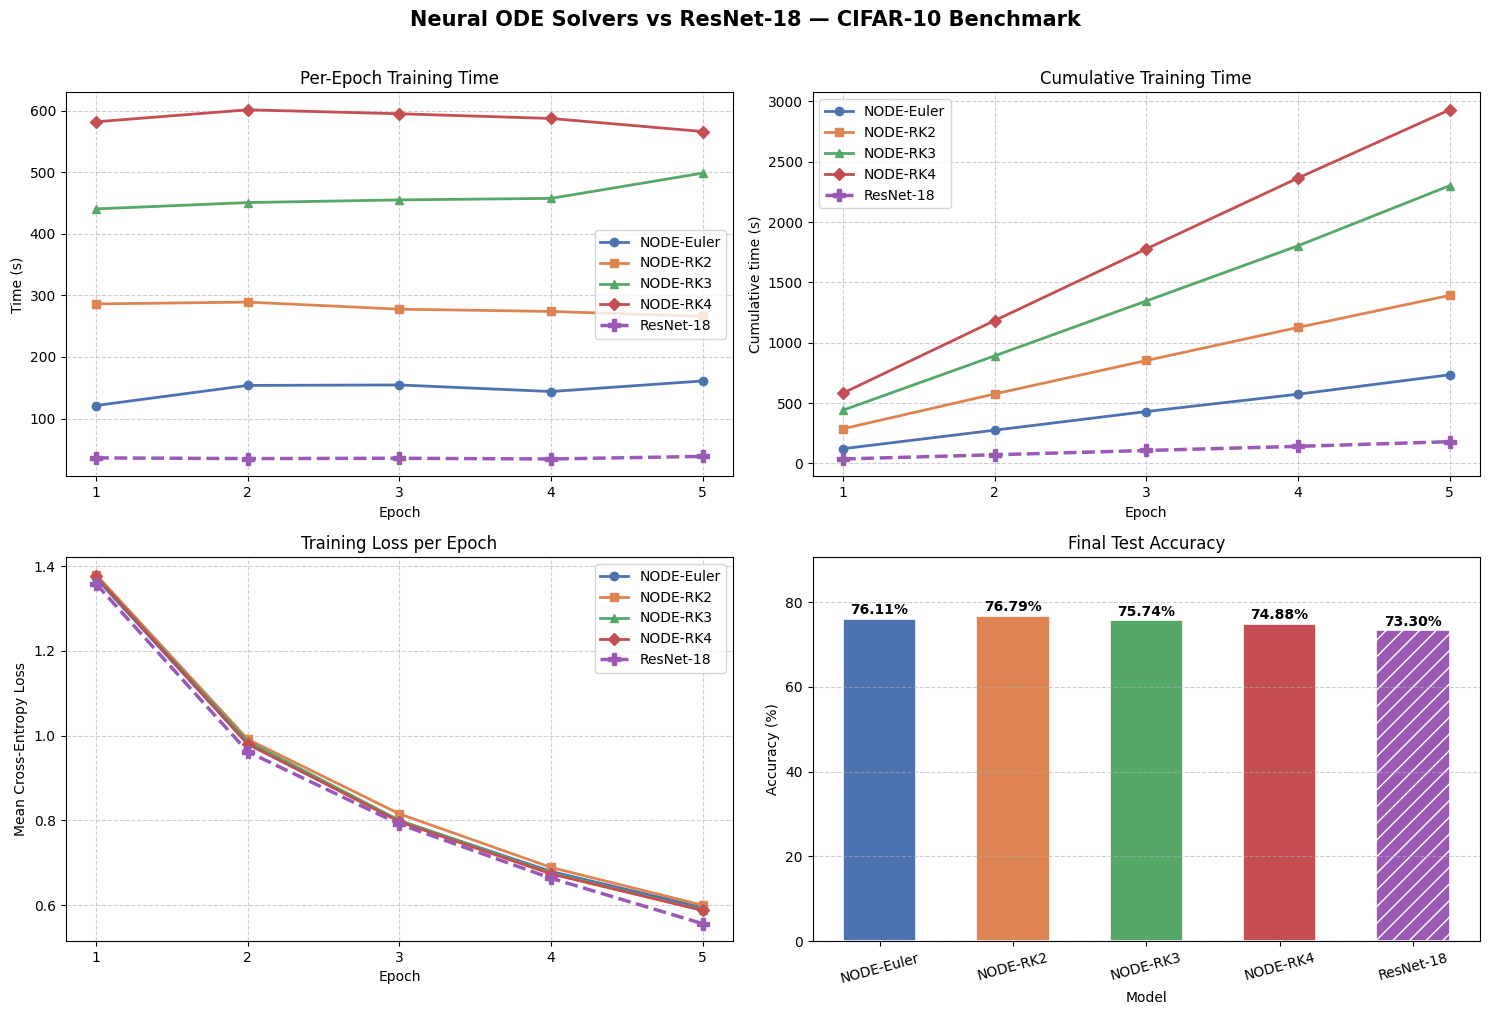

Figure saved to ode_vs_resnet_benchmark.png


In [16]:
# 5 entries: 4 Neural ODE solvers + ResNet-18
# ResNet-18 gets a distinct dashed style so it stands out as the baseline
NODE_COLORS  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']   # blue, orange, green, red
RESNET_COLOR = '#9B59B6'                                       # purple
MARKERS      = ['o', 's', '^', 'D', 'P']

all_items = list(all_results.items())

def style(name, idx):
    """Return plot kwargs for a given run."""
    if all_results[name]['model_type'] == 'resnet':
        return dict(color=RESNET_COLOR, marker='P', linewidth=2.5,
                    markersize=8, linestyle='--', zorder=5)
    return dict(color=NODE_COLORS[idx], marker=MARKERS[idx],
                linewidth=2, markersize=6, linestyle='-')

bar_colors = [RESNET_COLOR if all_results[n]['model_type'] == 'resnet'
              else NODE_COLORS[i] for i, (n, _) in enumerate(all_items)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Neural ODE Solvers vs ResNet-18 — CIFAR-10 Benchmark',
             fontsize=15, fontweight='bold', y=1.01)

# ---- Plot 1: Per-epoch training time ----
ax = axes[0, 0]
for idx, (name, r) in enumerate(all_items):
    ax.plot(r['epochs'], r['epoch_times'], label=name, **style(name, idx))
ax.set_title('Per-Epoch Training Time')
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# ---- Plot 2: Cumulative training time ----
ax = axes[0, 1]
for idx, (name, r) in enumerate(all_items):
    ax.plot(r['epochs'], r['cumulative_times'], label=name, **style(name, idx))
ax.set_title('Cumulative Training Time')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cumulative time (s)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# ---- Plot 3: Train loss curves ----
ax = axes[1, 0]
for idx, (name, r) in enumerate(all_items):
    ax.plot(r['epochs'], r['train_losses'], label=name, **style(name, idx))
ax.set_title('Training Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Cross-Entropy Loss')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# ---- Plot 4: Final test accuracy bar chart ----
ax = axes[1, 1]
names    = [name for name, _ in all_items]
test_acc = [r['test_accuracy'] for _, r in all_items]
bars = ax.bar(names, test_acc, color=bar_colors, width=0.55,
              edgecolor='white', linewidth=1.2)

# hatching on ResNet bar to make it instantly recognisable
for bar, (name, _) in zip(bars, all_items):
    if all_results[name]['model_type'] == 'resnet':
        bar.set_hatch('//')

ax.set_title('Final Test Accuracy')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, max(test_acc) * 1.18)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, acc in zip(bars, test_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ode_vs_resnet_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ode_vs_resnet_benchmark.png")